# Тест paddle ocr 


#### Зависимости

In [2]:
from pathlib import Path
import ast

import cv2
import pandas as pd
import numpy as np

from paddleocr import PaddleOCR
import easyocr


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


#### Чтение датасета с метками

In [3]:
df = pd.read_csv("../data/WaterMeters/data.csv")

df.head()

,photo_name,value,location
0,id_53_value_595_825.jpg,595.825,"{'type': 'polygon', 'data': [{'x': 0.30788, 'y..."
1,id_553_value_65_475.jpg,65.475,"{'type': 'polygon', 'data': [{'x': 0.26133, 'y..."
2,id_407_value_21_86.jpg,21.860,"{'type': 'polygon', 'data': [{'x': 0.27545, 'y..."
3,id_252_value_313_322.jpg,313.322,"{'type': 'polygon', 'data': [{'x': 0.21967, 'y..."
4,id_851_value_305_162.jpg,305.162,"{'type': 'polygon', 'data': [{'x': 0.06983, 'y..."


#### Преобразование json-многоугольника к прямоугольнику

Больше не применяется, так как не поварачивает изображение, обрезает изображение, захватывая лишнюю информацию 

In [4]:
def polygon_to_bbox(location_str, width, height):
    data = ast.literal_eval(location_str)

    points = data["data"]

    xs = [p["x"] for p in points]
    ys = [p["y"] for p in points]

    x_min = int(min(xs) * width)
    x_max = int(max(xs) * width)

    y_min = int(min(ys) * height)
    y_max = int(max(ys) * height)

    return x_min, y_min, x_max, y_max

In [17]:
def order_points(pts):
    """
    Упорядочивает 4 точки прямоугольника так, чтобы длинные стороны были горизонтальными.
    Возвращает: TL, TR, BR, BL (Top-Left, Top-Right, Bottom-Right, Bottom-Left)
    """
    # Вычисляем длины всех 4 сторон
    sides = []
    for i in range(4):
        p1 = pts[i]
        p2 = pts[(i + 1) % 4]
        length = np.linalg.norm(p2 - p1)
        sides.append((length, i, (i + 1) % 4))
    
    # Сортируем стороны по длине (убывание)
    sides.sort(key=lambda x: x[0], reverse=True)
    
    # Две самые длинные стороны — это противоположные стороны прямоугольника
    long_side1 = sides[0]
    long_side2 = sides[1]
    
    # Получаем индексы точек для длинных сторон
    idx1 = [long_side1[1], long_side1[2]]
    idx2 = [long_side2[1], long_side2[2]]
    
    # Определяем, какие точки образуют "верхнюю" сторону
    # Верхняя сторона — та, у которой y-координаты меньше (ближе к верху изображения)
    side1_y = (pts[idx1[0]][1] + pts[idx1[1]][1]) / 2
    side2_y = (pts[idx2[0]][1] + pts[idx2[1]][1]) / 2
    
    if side1_y < side2_y:
        top_pts = [pts[idx1[0]], pts[idx1[1]]]
        bottom_pts = [pts[idx2[0]], pts[idx2[1]]]
    else:
        top_pts = [pts[idx2[0]], pts[idx2[1]]]
        bottom_pts = [pts[idx1[0]], pts[idx1[1]]]
    
    # Упорядочиваем верхние точки: TL (левее), TR (правее)
    if top_pts[0][0] < top_pts[1][0]:
        tl, tr = top_pts[0], top_pts[1]
    else:
        tl, tr = top_pts[1], top_pts[0]
    
    # Упорядочиваем нижние точки: BL (левее), BR (правее)
    if bottom_pts[0][0] < bottom_pts[1][0]:
        bl, br = bottom_pts[0], bottom_pts[1]
    else:
        bl, br = bottom_pts[1], bottom_pts[0]
    
    return np.array([tl, tr, br, bl], dtype=np.float32)


In [32]:
def get_rotated_crop(image, location_str):
    # 1. Парсим строку
    try:
        loc_dict = ast.literal_eval(location_str)
    except Exception:
        import json
        loc_dict = json.loads(location_str)
        
    points_data = loc_dict['data']
    h, w = image.shape[:2]
    
    # 2. Переводим в пиксели
    pts = np.array([[p['x'] * w, p['y'] * h] for p in points_data], dtype=np.float32)
    
    if len(pts) < 3:
        raise ValueError("Полигон должен содержать минимум 3 точки")
        
    # 3. Минимальный описывающий прямоугольник
    rect = cv2.minAreaRect(pts)
    box = cv2.boxPoints(rect)
    
    # 4. Упорядочиваем углы с учетом ориентации (ИСПРАВЛЕНИЕ)
    ordered_pts = order_points(box)
    
    # 5. Размеры нового изображения
    widthA = np.linalg.norm(ordered_pts[2] - ordered_pts[3])
    widthB = np.linalg.norm(ordered_pts[1] - ordered_pts[0])
    maxWidth = max(int(widthA), int(widthB))
    
    heightA = np.linalg.norm(ordered_pts[1] - ordered_pts[2])
    heightB = np.linalg.norm(ordered_pts[0] - ordered_pts[3])
    maxHeight = max(int(heightA), int(heightB))
    
    if maxWidth <= 0 or maxHeight <= 0:
        raise ValueError("Вычисленные размеры кропа меньше или равны нулю")

    # 6. Задаем целевые точки
    dst_pts = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype=np.float32).reshape(4, 2)
    
    # 7. Применяем трансформацию
    ordered_pts = ordered_pts.astype(np.float32).reshape(4, 2)
    
    M = cv2.getPerspectiveTransform(ordered_pts, dst_pts)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))
    
    return warped

#### Визуальная проверка на первой фотке

(np.float64(-0.5), np.float64(517.5), np.float64(95.5), np.float64(-0.5))

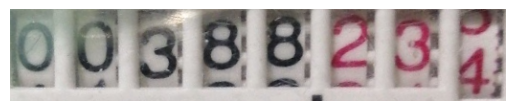

In [19]:
import matplotlib.pyplot as plt

row = df.iloc[308]

img = cv2.imread(
    f"../data/WaterMeters/images/{row.photo_name}"
)

assert img is not None
img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

crop = get_rotated_crop(
    img,
    row.location
)

plt.imshow(crop)
plt.axis("off")

#### Создание модели

In [ ]:
paddle_ocr = PaddleOCR(
    use_textline_orientation=False,
    lang="en", 
    det=False
)

# from paddleocr import TextRecognition
# paddle_ocr = TextRecognition()


ValueError: Unknown argument: det

In [35]:
easy_ocr = easyocr.Reader(
    ['en'],
    gpu=False)

[2026-06-25 14:12:35,028] [ WARNING] easyocr.py:71 - Using CPU. Note: This module is much faster with a GPU.


#### Функция для получение прямоугольника и правильного ответа

In [22]:
def get_crop(photo_name):
    row = df.loc[
        df["photo_name"] == photo_name
    ].iloc[0]

    img = cv2.imread(
        f"../data/WaterMeters/images/{photo_name}"
    )

    if img is None:
        raise FileNotFoundError(photo_name)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    crop = get_rotated_crop(
        img,
        row.location
    )

    return crop, row["value"]

#### Функция распознавания для paddle

In [23]:
import re

def recognize_crop_paddle(crop):
    return paddle_ocr.predict(crop)

def extract_text_paddle(result):
    texts = result[0]["rec_texts"]

    text = "".join(texts)

    return re.sub(
        r"[^0-9.,]",
        "",
        text
    )

#### Функция распознавания для easy

In [24]:
def recognize_crop_easy(crop):
    return easy_ocr.recognize(
        crop,
        detail=1,
        allowlist="0123456789.,"
    )

def extract_text_easy(result):
    text = "".join(
        item[1]
        for item in result
    )

    return re.sub(
        r"[^0-9.,]",
        "",
        text
    )

In [25]:
# test_files = [
#     "id_1_value_13_116.jpg",
#     'id_2_value_495_341.jpg',
#     "id_295_value_337_925.jpg",
#     "id_1206_value_33_069.jpg",
#     'id_1234_value_850_0.jpg'
# ]

images_dir = Path("../data/WaterMeters/images")

test_files =  [f.name for f in images_dir.glob("*.jpg")][30:60]


print(test_files[:5])

['id_1028_value_125_489.jpg', 'id_1029_value_409_55.jpg', 'id_102_value_351_091.jpg', 'id_1030_value_128_318.jpg', 'id_1031_value_199_337.jpg']


In [26]:
def normalize_value(value: str) -> str:
    value = str(value).strip()
    value = value.replace(",", ".")
    value = re.sub(r"[^0-9.]", "", value)

    return value    

#### Отрисовка прямоугольников на цифрах

In [27]:
def draw_paddle_boxes(crop, paddle_result):
    img = crop.copy()

    for poly in paddle_result[0]["dt_polys"]:

        pts = np.array(
            poly,
            dtype=np.int32
        )

        cv2.polylines(
            img,
            [pts],
            isClosed=True,
            color=(255, 0, 0),  # красный в RGB
            thickness=2
        )

    return img

def draw_paddle_boxes_rec(crop, paddle_result):
    img = crop.copy()
    

    for poly in paddle_result[0]:

        pts = np.array(
            poly,
            dtype=np.int32
        )

        cv2.polylines(
            img,
            [pts],
            isClosed=True,
            color=(255, 0, 0),  # красный в RGB
            thickness=2
        )

    return img


def draw_easy_boxes(crop, easy_result):
    img = crop.copy()

    for box, text, score in easy_result:

        pts = np.array(
            box,
            dtype=np.int32
        )

        cv2.polylines(
            img,
            [pts],
            isClosed=True,
            color=(0, 255, 0),  # зеленый в RGB
            thickness=2
        )

    return img

In [28]:
def preprocess_crop(crop):
    gray = cv2.cvtColor(
        crop,
        cv2.COLOR_RGB2GRAY
    )

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_GRAY2RGB
    )

    return enhanced

#### Резульат

c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


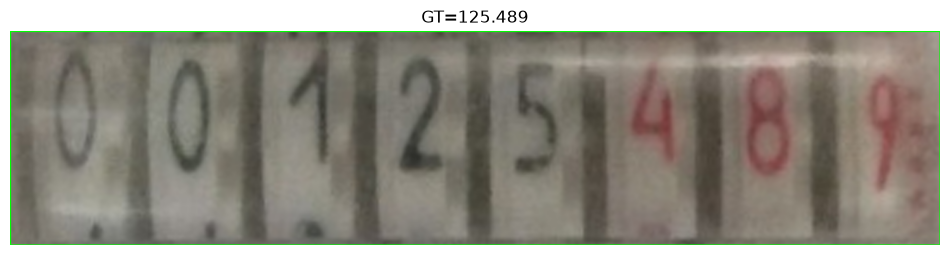

FILE: id_1028_value_125_489.jpg
CROP SHAPE:  (360, 1564, 3)
GT  : 125.489
PADDLE OCR : 00125489
EASY OCR : 70406924514819


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


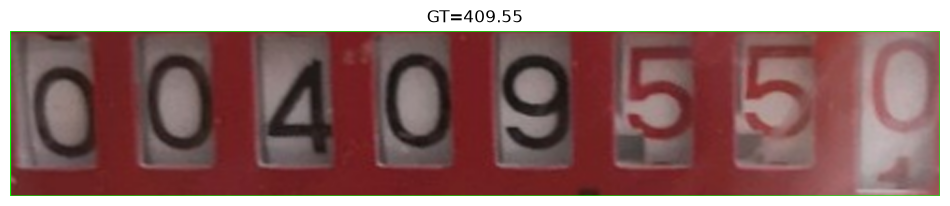

FILE: id_1029_value_409_55.jpg
CROP SHAPE:  (308, 1732, 3)
GT  : 409.55
PADDLE OCR : 00409550
EASY OCR : 60410956.0


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


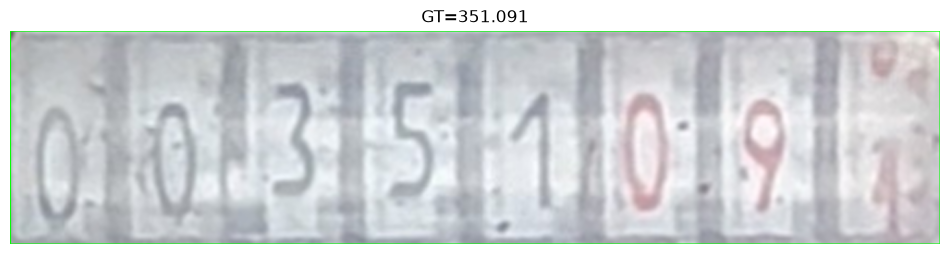

FILE: id_102_value_351_091.jpg
CROP SHAPE:  (392, 1708, 3)
GT  : 351.091
PADDLE OCR : 01035109
EASY OCR : 080434544404244


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


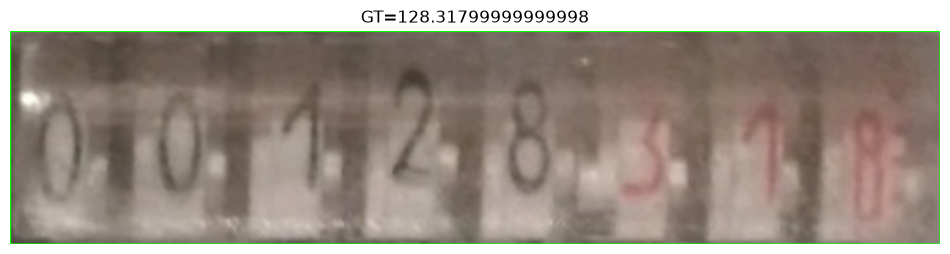

FILE: id_1030_value_128_318.jpg
CROP SHAPE:  (352, 1536, 3)
GT  : 128.31799999999998
PADDLE OCR : 010128318
EASY OCR : 01014278416


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


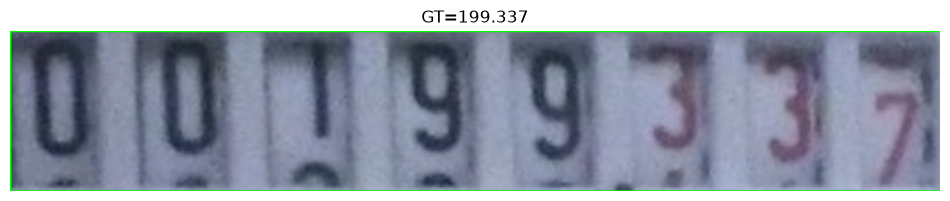

FILE: id_1031_value_199_337.jpg
CROP SHAPE:  (228, 1324, 3)
GT  : 199.337
PADDLE OCR : 00199337
EASY OCR : 07072499337


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


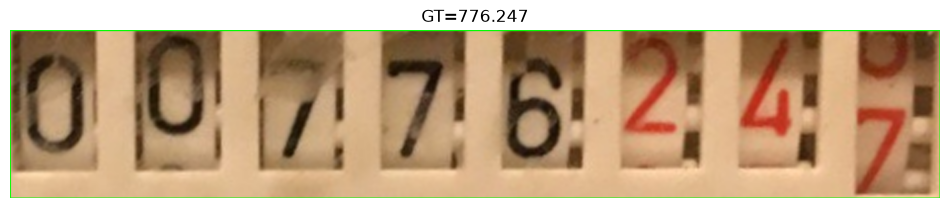

FILE: id_1032_value_776_247.jpg
CROP SHAPE:  (340, 1884, 3)
GT  : 776.247
PADDLE OCR : 0076242
EASY OCR : 101174746.247


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


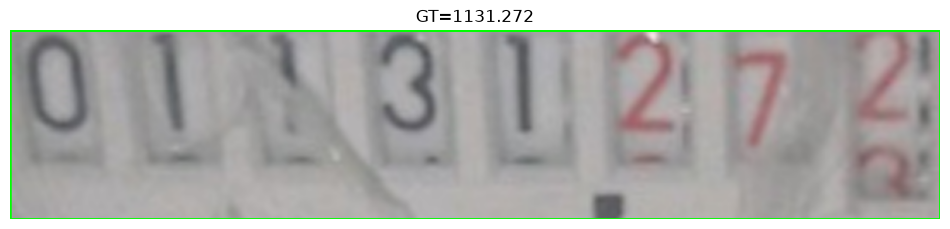

FILE: id_1033_value_1131_272.jpg
CROP SHAPE:  (220, 1084, 3)
GT  : 1131.272
PADDLE OCR : 0130272
EASY OCR : 01134272


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


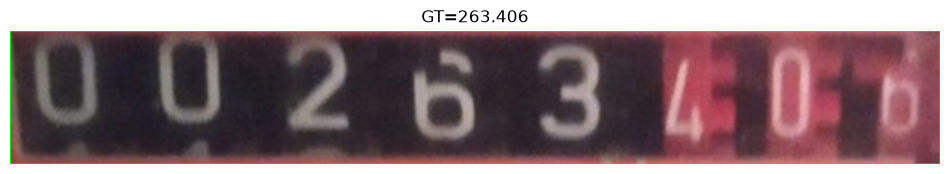

FILE: id_1034_value_263_406.jpg
CROP SHAPE:  (284, 1980, 3)
GT  : 263.406
PADDLE OCR : 00263400
EASY OCR : 002634076


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


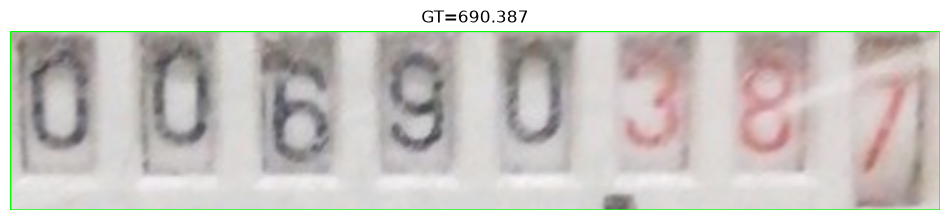

FILE: id_1035_value_690_387.jpg
CROP SHAPE:  (272, 1412, 3)
GT  : 690.387
PADDLE OCR : 00690387
EASY OCR : 00.690.38.7


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


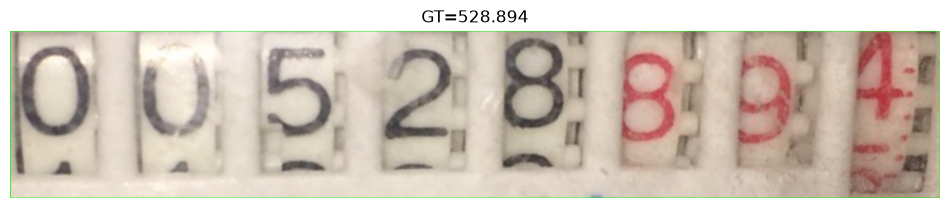

FILE: id_1036_value_528_894.jpg
CROP SHAPE:  (444, 2468, 3)
GT  : 528.894
PADDLE OCR : 00528894
EASY OCR : 915288914


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


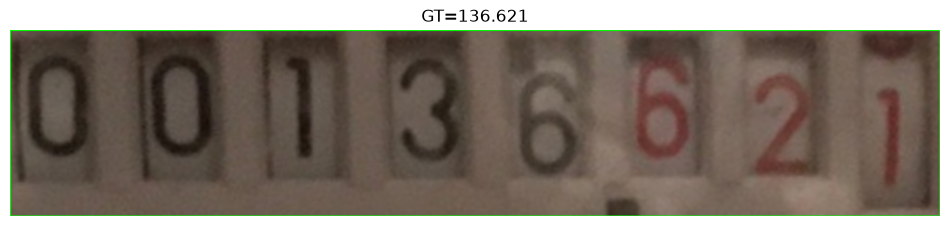

FILE: id_1037_value_136_621.jpg
CROP SHAPE:  (352, 1760, 3)
GT  : 136.621
PADDLE OCR : 00036621
EASY OCR : 00.00.03.6.8.21


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


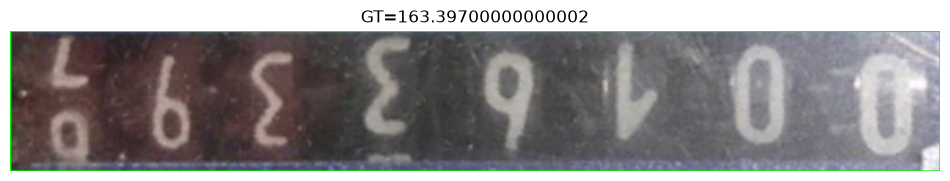

FILE: id_1038_value_163_397.jpg
CROP SHAPE:  (216, 1432, 3)
GT  : 163.39700000000002
PADDLE OCR : 66289400
EASY OCR : 6..6899100


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


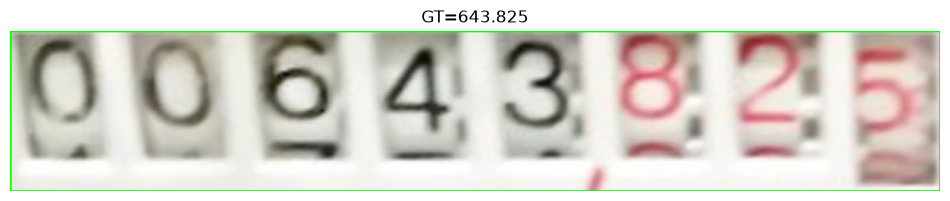

FILE: id_1039_value_643_825.jpg
CROP SHAPE:  (204, 1184, 3)
GT  : 643.825
PADDLE OCR : 00643825
EASY OCR : 902438251


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


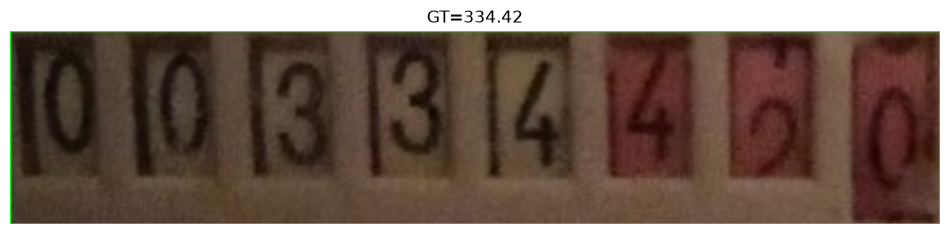

FILE: id_103_value_334_42.jpg
CROP SHAPE:  (304, 1464, 3)
GT  : 334.42
PADDLE OCR : 00334480
EASY OCR : 1101864.


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


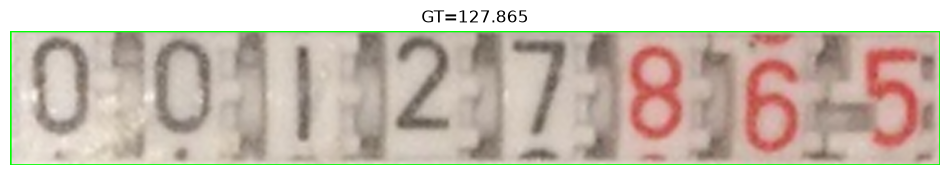

FILE: id_1040_value_127_865.jpg
CROP SHAPE:  (164, 1136, 3)
GT  : 127.865
PADDLE OCR : 00127865
EASY OCR : 0404142.7.81625


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


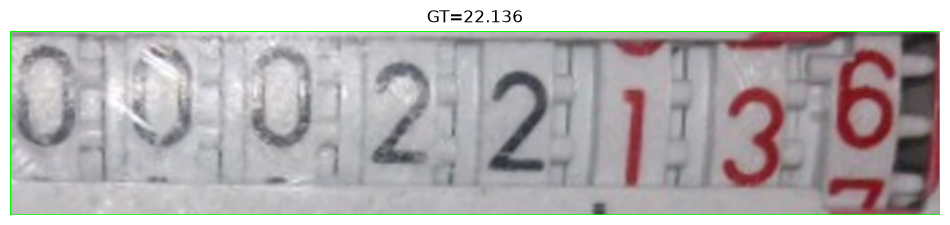

FILE: id_1041_value_22_136.jpg
CROP SHAPE:  (272, 1372, 3)
GT  : 22.136
PADDLE OCR : 00022136
EASY OCR : 0191912.121113.8


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


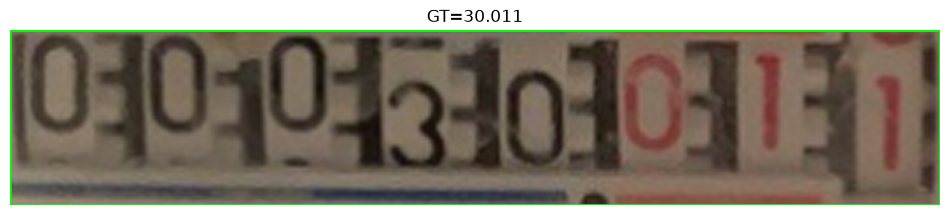

FILE: id_1042_value_30_011.jpg
CROP SHAPE:  (200, 1064, 3)
GT  : 30.011
PADDLE OCR : 10010300
EASY OCR : 040101310703131


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


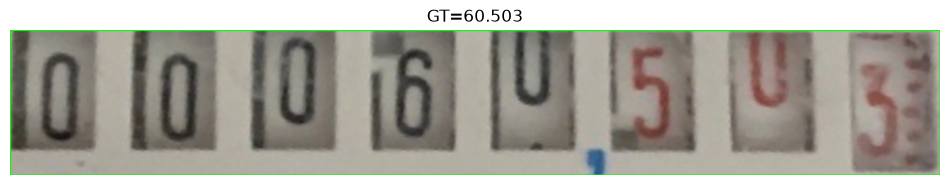

FILE: id_1043_value_60_503.jpg
CROP SHAPE:  (280, 1796, 3)
GT  : 60.503
PADDLE OCR : 605
EASY OCR : 10604016300457146


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


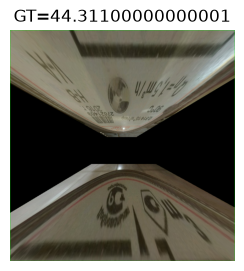

FILE: id_1044_value_44_311.jpg
CROP SHAPE:  (2296, 2232, 3)
GT  : 44.31100000000001
PADDLE OCR : 
EASY OCR : 7


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


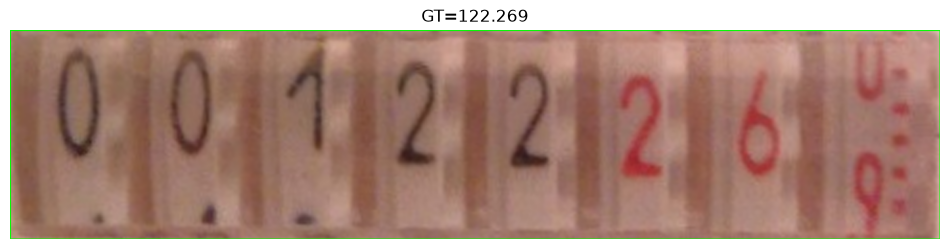

FILE: id_1045_value_122_269.jpg
CROP SHAPE:  (400, 1780, 3)
GT  : 122.269
PADDLE OCR : 0012226
EASY OCR : 6010.421212463


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


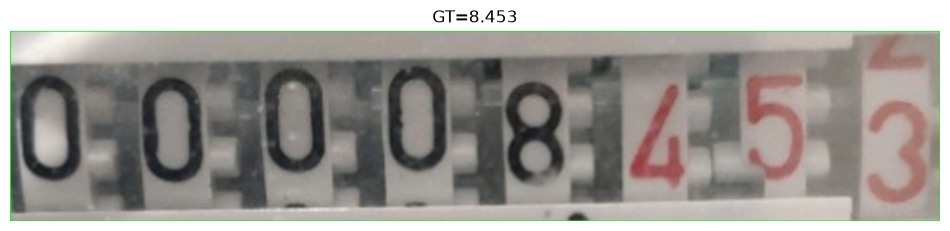

FILE: id_1046_value_8_453.jpg
CROP SHAPE:  (392, 1916, 3)
GT  : 8.453
PADDLE OCR : 00008453
EASY OCR : 0.04040.8141513


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


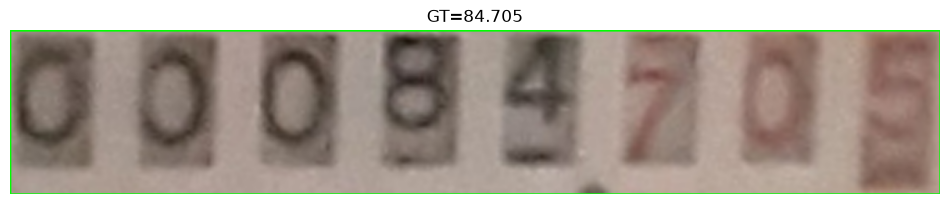

FILE: id_1047_value_84_705.jpg
CROP SHAPE:  (236, 1340, 3)
GT  : 84.705
PADDLE OCR : 0000420
EASY OCR : 00084705


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


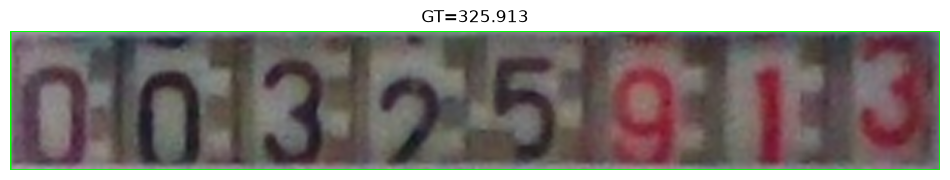

FILE: id_1048_value_325_913.jpg
CROP SHAPE:  (180, 1200, 3)
GT  : 325.913
PADDLE OCR : 01013259113
EASY OCR : 0113759313


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


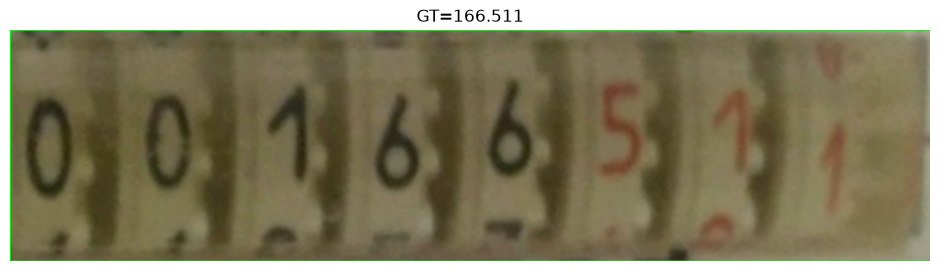

FILE: id_1049_value_166_511.jpg
CROP SHAPE:  (520, 2072, 3)
GT  : 166.511
PADDLE OCR : 00166511
EASY OCR : 0.0736151541.


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


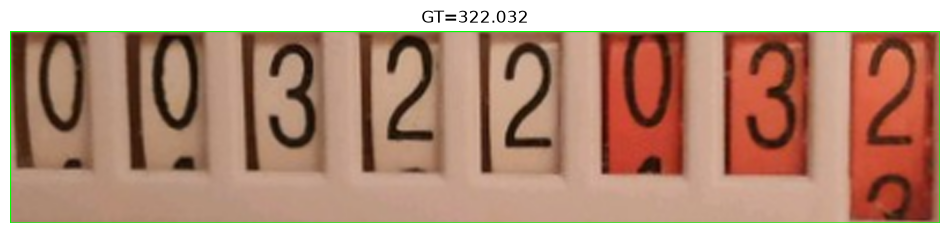

FILE: id_104_value_322_032.jpg
CROP SHAPE:  (332, 1608, 3)
GT  : 322.032
PADDLE OCR : 00322932
EASY OCR : 40121312121112


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


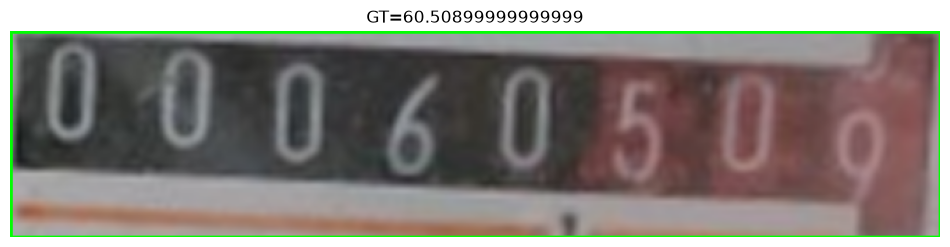

FILE: id_1050_value_60_509.jpg
CROP SHAPE:  (148, 668, 3)
GT  : 60.50899999999999
PADDLE OCR : 00060500
EASY OCR : 000.6.0.5.0.9


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


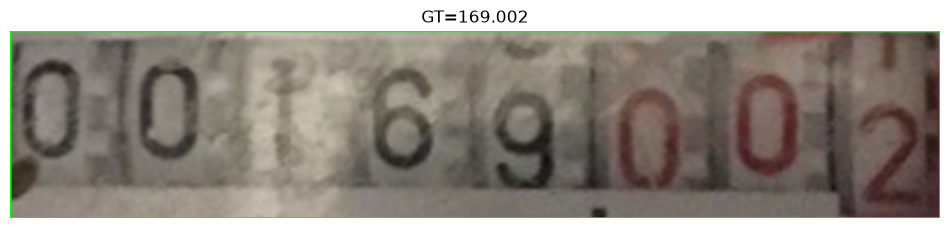

FILE: id_1051_value_169_002.jpg
CROP SHAPE:  (256, 1272, 3)
GT  : 169.002
PADDLE OCR : 010169101012
EASY OCR : 0.0081910.0.2


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


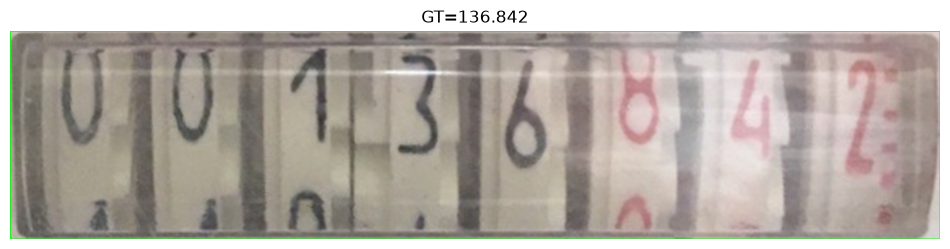

FILE: id_1052_value_136_842.jpg
CROP SHAPE:  (512, 2288, 3)
GT  : 136.842
PADDLE OCR : 001316842
EASY OCR : 01431819711


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


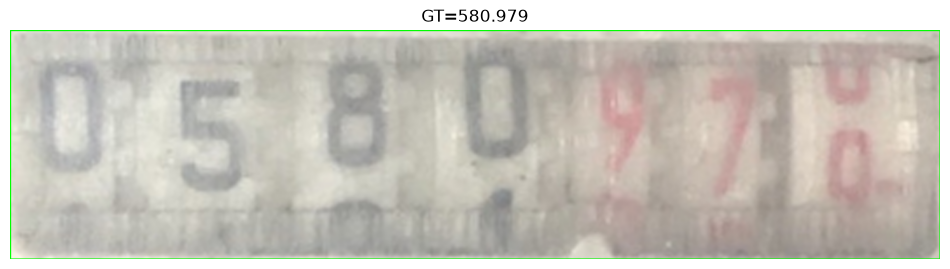

FILE: id_1053_value_580_979.jpg
CROP SHAPE:  (392, 1592, 3)
GT  : 580.979
PADDLE OCR : 0580978
EASY OCR : 0.5.8704971


c:\Users\user\AppData\Local\pypoetry\Cache\virtualenvs\ocr-g7OiDfSc-py3.13\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


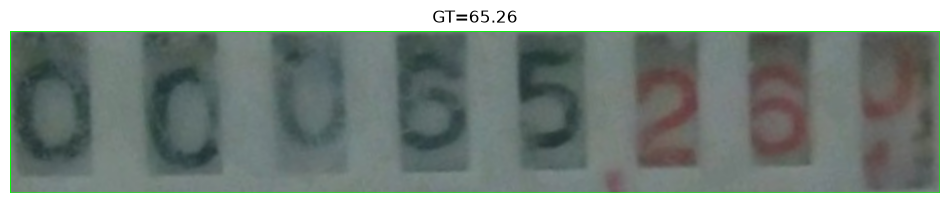

FILE: id_1054_value_65_26.jpg
CROP SHAPE:  (320, 1836, 3)
GT  : 65.26
PADDLE OCR : 06065269
EASY OCR : 00855287


In [33]:
from pprint import pprint


for file_name in test_files:

    crop, gt = get_crop(file_name)
    crop = cv2.resize(
    crop,
    None,
    fx=4,
    fy=4,
    interpolation=cv2.INTER_CUBIC)
    
    # crop = preprocess_crop(crop)



    paddle_result = recognize_crop_paddle(crop)
    easy_result = recognize_crop_easy(crop)

    # paddle_text = extract_text_paddle(
    #     paddle_result
    # )
    paddle_text = ''.join(map(lambda x: x['rec_text'].strip(), paddle_result))

    easy_text = extract_text_easy(
        easy_result
    )

    # paddle_img = draw_paddle_boxes_rec(
    # crop,
    # paddle_result
    # )

    easy_img = draw_easy_boxes(
        # paddle_img,
        crop,
        easy_result
    )

    plt.figure(figsize=(12,3))
    plt.imshow(easy_img)
    plt.title(f"GT={gt}")
    plt.axis("off")
    plt.show()
    print("FILE:", file_name)
    print('CROP SHAPE: ', crop.shape)
    print("GT  :", gt)
    print("PADDLE OCR :", normalize_value(paddle_text))
    print("EASY OCR :", normalize_value(easy_text))

    

#### Проблемы
- засвет
- шестеренки принимаются за цифры
- не читается дробная часть